In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import cross_val_score
from tensorflow.keras import layers


In [5]:
# Cargar el conjunto de datos
df = pd.read_csv('dataset/heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# ============================================================
# 0. CONVERSIÓN DEL DATASET CSV A XLSX
# ============================================================

print("\nShape final del DataFrame (filas, columnas):", df.shape)
print("\nVista final de las primeras filas:")
display(df.head())

print("\nTipos de datos finales:")
print(df.dtypes)

print("\nResumen de valores nulos después de limpieza:")
print(df.isna().sum())


df.to_excel("heart_clean.xlsx", index=False)
print("\nArchivo 'heart_clean.xlsx' guardado correctamente.")


Shape final del DataFrame (filas, columnas): (1025, 14)

Vista final de las primeras filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Tipos de datos finales:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Resumen de valores nulos después de limpieza:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Archivo 'heart_clean.xlsx' guardado correctamente.


In [7]:
# ============================================================
# 1. Lectura del nuevo archivo
# ============================================================
df_limpio = pd.read_excel('heart_clean.xlsx', header=0)

In [8]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
# ============================================================
# 2 ANÁLISIS Y TRATAMIENTO DE VALORES NULOS
# ============================================================

print("\nResumen de valores nulos por columna:")
nulos = df_limpio.isna().sum()
print(nulos)

# Visualización rápida de columnas con nulos
plt.figure()
nulos_filtrados = nulos[nulos > 0]
if len(nulos_filtrados) > 0:
    nulos_filtrados.plot(kind='bar')
    plt.title('Valores nulos por columna')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores nulos en el DataFrame.")



Resumen de valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
No se encontraron valores nulos en el DataFrame.


<Figure size 640x480 with 0 Axes>

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9204\560184942.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette='coolwarm')


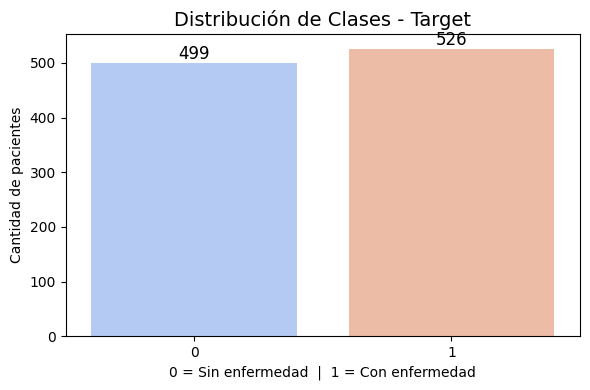

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='coolwarm')

# Etiquetas encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title("Distribución de Clases - Target", fontsize=14)
plt.xlabel("0 = Sin enfermedad  |  1 = Con enfermedad")
plt.ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

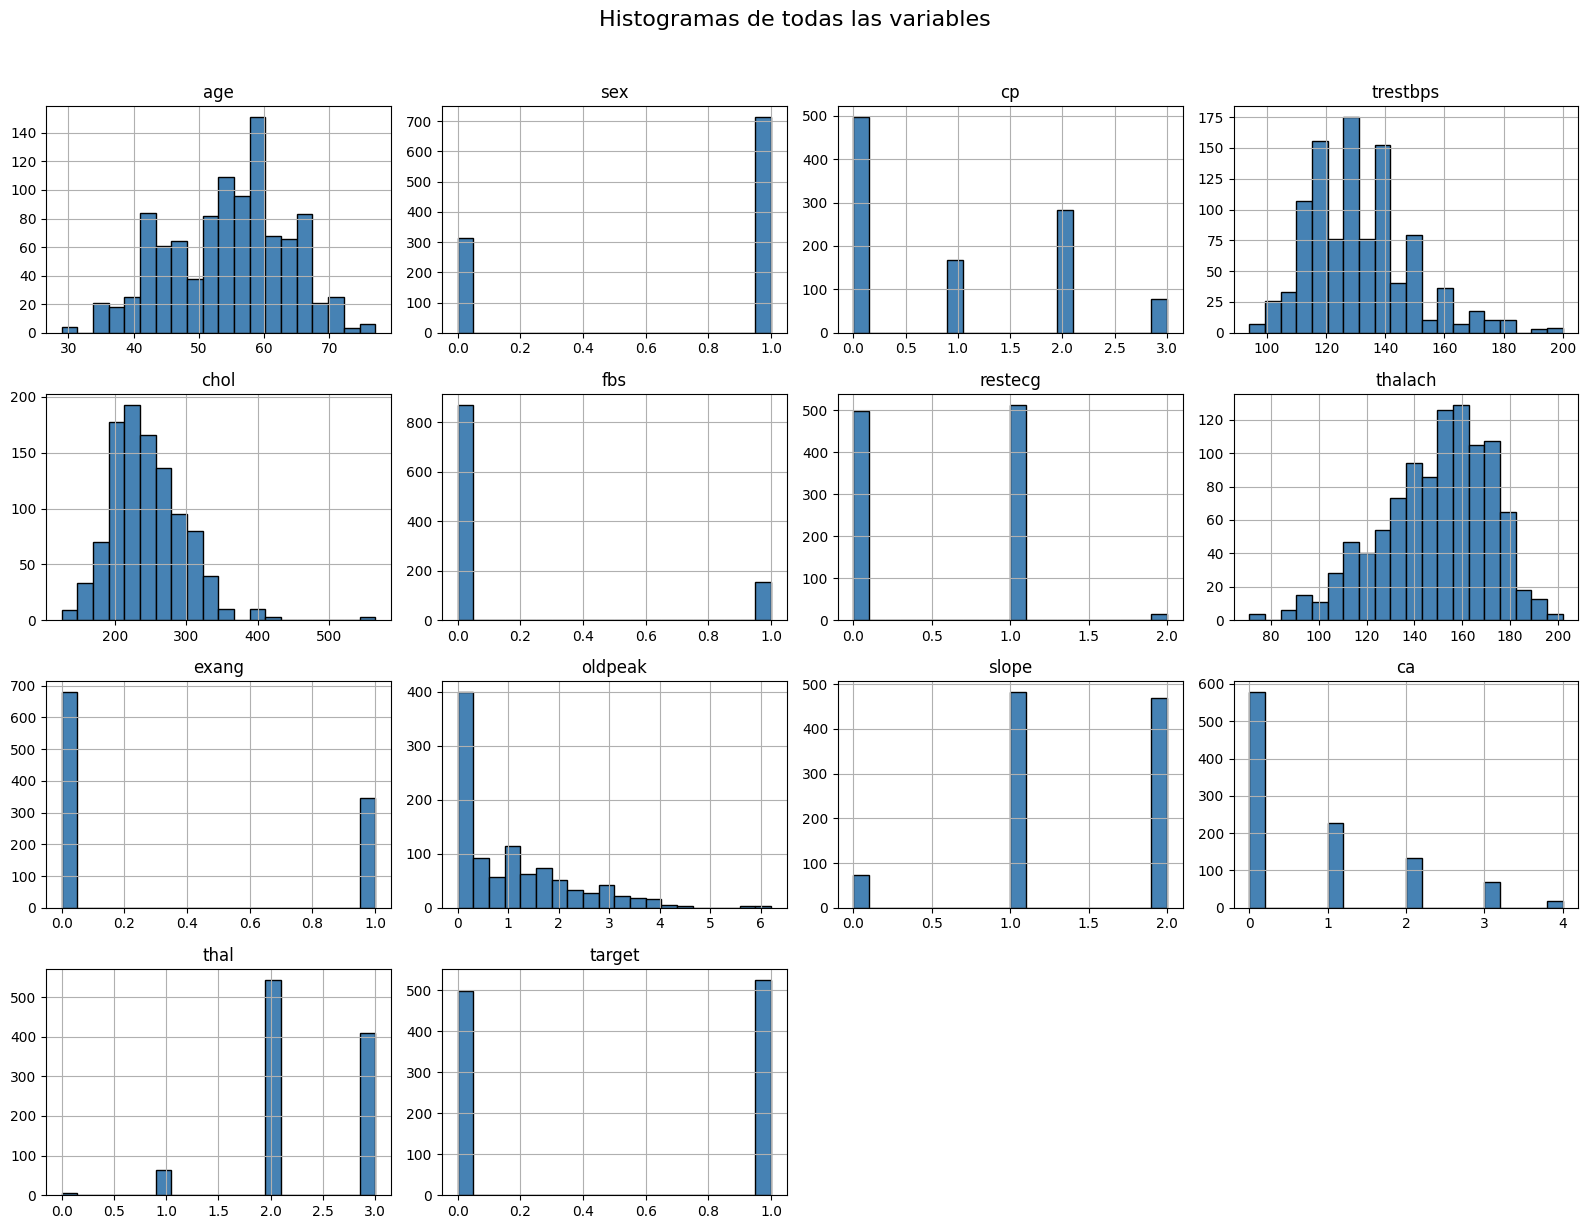

In [12]:
df.hist(figsize=(16, 12), 
        bins=20, 
        color='steelblue', 
        edgecolor='black')

plt.suptitle("Histogramas de todas las variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

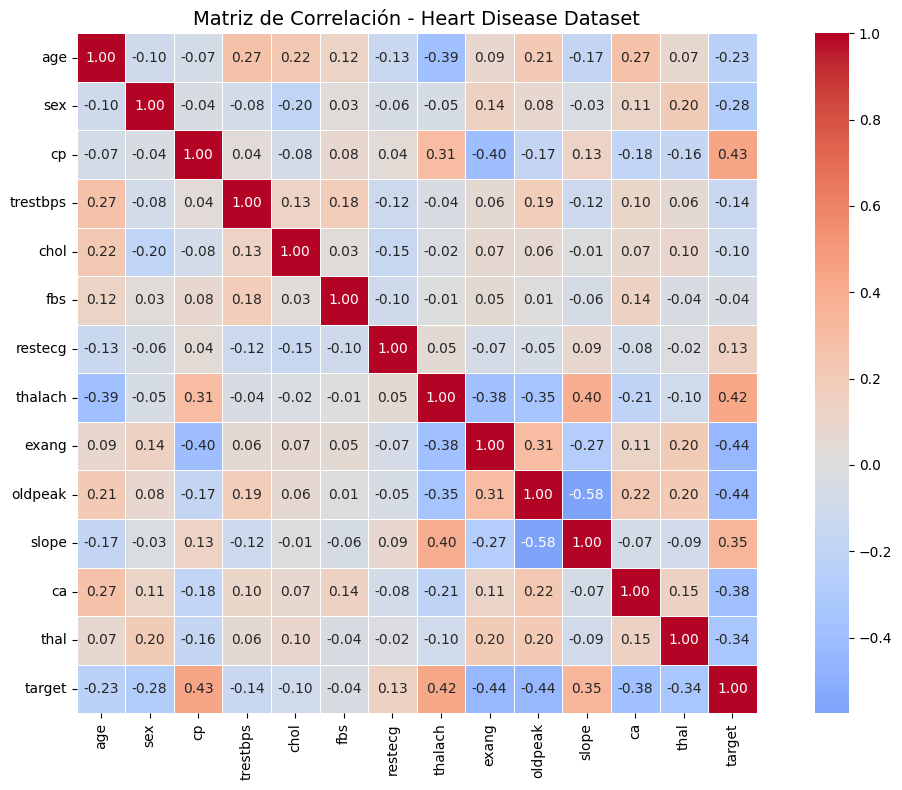

In [10]:
# =============================================
# MATRIZ DE CORRELACIÓN
# =============================================

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), 
            annot=True,          # muestra los valores
            fmt=".2f",           # 2 decimales
            cmap="coolwarm",     # colores rojo-azul
            center=0,            # centro en 0
            square=True,         # celdas cuadradas
            linewidths=0.5)

plt.title("Matriz de Correlación - Heart Disease Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df_encoded = pd.get_dummies(df_limpio, columns=['cp', 'restecg', 'slope', 'thal'], 
                             drop_first=True)

print("Columnas después del encoding:")
print(df_encoded.columns.tolist())
print(f"\nNuevo shape: {df_encoded.shape}")


df_limpio.info()

Columnas después del encoding:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']

Nuevo shape: (1025, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), in

Variable objetivo

target → es lo que queremos predecir

In [15]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1025, 19)
y shape: (1025,)


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados correctamente")
print(f"Media aproximada: {X_scaled.mean():.4f}")
print(f"Desviación estándar aproximada: {X_scaled.std():.4f}")

Datos normalizados correctamente
Media aproximada: -0.0000
Desviación estándar aproximada: 1.0000


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,       # 80% entrenamiento, 20% prueba
    random_state=42,     # reproducibilidad
    stratify=y           # mantiene proporción de clases (importante por el desbalance)
)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")
print(f"\nDistribución en train:")
print(pd.Series(y_train).value_counts())
print(f"\nDistribución en test:")
print(pd.Series(y_test).value_counts())

Datos de entrenamiento: (820, 19)
Datos de prueba: (205, 19)

Distribución en train:
target
1    421
0    399
Name: count, dtype: int64

Distribución en test:
target
1    105
0    100
Name: count, dtype: int64


In [18]:
# =============================================
# FASE 4 - MODELO 1: PERCEPTRÓN
# =============================================

from sklearn.linear_model import Perceptron

perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X_train, y_train)

print("Perceptrón entrenado correctamente ✅")

Perceptrón entrenado correctamente ✅


RESULTADOS - PERCEPTRÓN
Accuracy:  0.7902
Precision: 0.7422
Recall:    0.9048
F1-Score:  0.8155


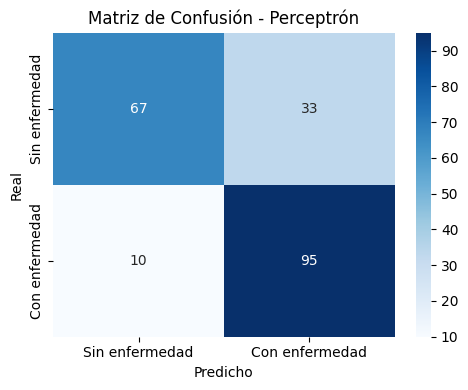

In [20]:
y_pred_perceptron = perceptron.predict(X_test)

print("=" * 40)
print("RESULTADOS - PERCEPTRÓN")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_perceptron):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_perceptron):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_perceptron):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_perceptron):.4f}")



cm = confusion_matrix(y_test, y_pred_perceptron)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin enfermedad', 'Con enfermedad'],
            yticklabels=['Sin enfermedad', 'Con enfermedad'])
plt.title("Matriz de Confusión - Perceptrón")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

In [29]:
# =============================================
# FASE 4 - MODELO 2: MLP (Red Neuronal Multicapa)
# =============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

tf.random.set_seed(42)
np.random.seed(42)

mlp = Sequential([
    Dense(16, activation='relu', 
          kernel_regularizer=regularizers.l2(0.01),
          input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(8, activation='relu',
          kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', 
                           patience=20,
                           restore_best_weights=True)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
history_mlp = mlp.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=True
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4970 - loss: 1.2585 - val_accuracy: 0.5793 - val_loss: 0.9908
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5518 - loss: 1.1225 - val_accuracy: 0.6463 - val_loss: 0.8943
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5747 - loss: 1.0049 - val_accuracy: 0.7073 - val_loss: 0.8403
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6311 - loss: 0.9351 - val_accuracy: 0.7622 - val_loss: 0.8036
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6753 - loss: 0.8442 - val_accuracy: 0.7805 - val_loss: 0.7719
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6463 - loss: 0.8819 - val_accuracy: 0.7988 - val_loss: 0.7455
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6448 - loss: 0.8352 - val_accuracy: 0.8110 - val_loss: 0.7225
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6677 - loss: 0.8212 - val_accuracy: 0.8476 - 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RESULTADOS - MLP
Accuracy:  0.8976
Precision: 0.8818
Recall:    0.9238
F1-Score:  0.9023


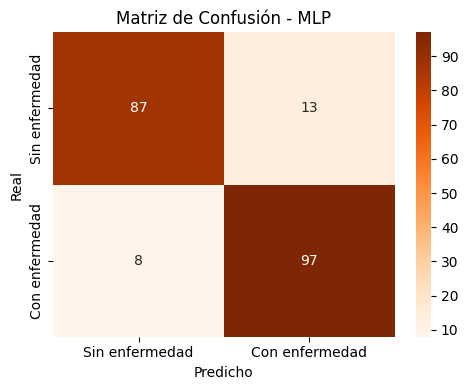

In [31]:
y_pred_mlp_prob = mlp.predict(X_test)
y_pred_mlp = (y_pred_mlp_prob > 0.5).astype(int)

print("=" * 40)
print("RESULTADOS - MLP")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_mlp):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_mlp):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_mlp):.4f}")

# Matriz de confusión
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin enfermedad', 'Con enfermedad'],
            yticklabels=['Sin enfermedad', 'Con enfermedad'])
plt.title("Matriz de Confusión - MLP")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

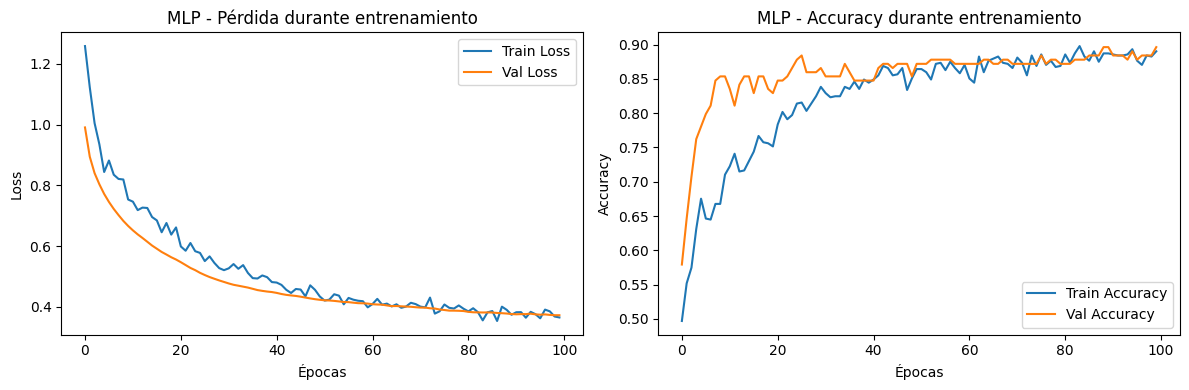

In [32]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')
plt.title("MLP - Pérdida durante entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')
plt.title("MLP - Accuracy durante entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# =============================================
# MODELO 3: DNN (Deep Neural Network)
# =============================================

tf.random.set_seed(42)

dnn = Sequential([
    # Capa de entrada
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    
    # Capas ocultas profundas
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    
    # Capa de salida
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

early_stop_dnn = EarlyStopping(monitor='val_loss',
                                patience=20,
                                restore_best_weights=True)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
history_dnn = dnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_dnn],
    verbose=True
)
dnn.summary()

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5884 - loss: 0.6702 - val_accuracy: 0.7561 - val_loss: 0.6366
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7012 - loss: 0.6202 - val_accuracy: 0.8415 - val_loss: 0.5637
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7287 - loss: 0.5620 - val_accuracy: 0.8049 - val_loss: 0.4816
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7896 - loss: 0.4847 - val_accuracy: 0.8049 - val_loss: 0.4210
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8034 - loss: 0.4548 - val_accuracy: 0.8476 - val_loss: 0.3924
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8232 - loss: 0.3957 - val_accuracy: 0.8354 - val_loss: 0.3770
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8277 - loss: 0.4142 - val_accuracy: 0.8354 - val_loss: 0.3703
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8460 - loss: 0.3845 - val_accuracy: 0.8415 - 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,101 (47.27 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,068 (31.52 KB)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
RESULTADOS - DNN
Accuracy:  0.9902
Precision: 1.0000
Recall:    0.9810
F1-Score:  0.9904


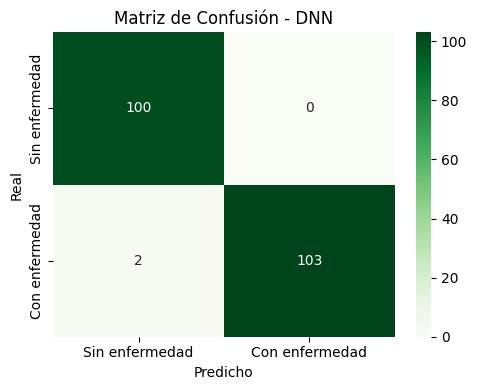

In [35]:
y_pred_dnn_prob = dnn.predict(X_test)
y_pred_dnn = (y_pred_dnn_prob > 0.5).astype(int)

print("=" * 40)
print("RESULTADOS - DNN")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dnn):.4f}")

cm_dnn = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin enfermedad', 'Con enfermedad'],
            yticklabels=['Sin enfermedad', 'Con enfermedad'])
plt.title("Matriz de Confusión - DNN")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()